Delegate: Tan De Jiun  
Date: 03 May 2026

## 1. Introduction


### 1.1 Finance problem
The fair price of a European derivative is the discounted expected payoff under the risk-neutral measure $\mathbb{Q}$,
$$
V(S,\, t) = e^{-r (T - t)} \mathbb{E}^\mathbb{Q}\left[\text{Payoff}(S_T) \,\big|\, S_t = S\right].
$$

Under $\mathbb{Q}$, the stock follows geometric Brownian motion,
$$
dS_t = r S_t dt + \sigma S_t dX_t^\mathbb{Q},
$$

To solve for $S_T$ explicitly, apply Itô's lemma to $f(S_t) = \ln S_t$. Taking the required partial derivatives,
$$
\frac{\partial f}{\partial S_t} = \frac{1}{S_t}, \qquad \frac{\partial^2 f}{\partial S_t^2} = -\frac{1}{S_t^2}.
$$

Itô's lemma for a function of a diffusion $dS_t = a dt + b dX_t$ states
$$
df(S_t) = \frac{\partial f}{\partial S_t} dS_t + \frac{1}{2} \frac{\partial^2 f}{\partial S_t^2} (dS_t)^2.
$$

Substituting $dS_t = r S_t dt + \sigma S_t dX_t^\mathbb{Q}$ and using the Itô multiplication rule $(dX_t^\mathbb{Q})^2 = dt$,
$$
(dS_t)^2 = \sigma^2 S_t^2 dt.
$$

Altogether, we have
$$
d(\ln S_t) = \frac{1}{S_t}\bigl(r S_t dt + \sigma S_t dX_t^\mathbb{Q}\bigr) + \frac{1}{2}\left(-\frac{1}{S_t^2}\right)\sigma^2 S_t^2 dt = \left(r - \frac{1}{2} \sigma^2\right) dt + \sigma dX_t^\mathbb{Q}.
$$

This is an ordinary drift–diffusion with constant coefficients, so integrating both sides from $t$ to $T$ gives
$$
\begin{aligned}
\ln S_T - \ln S_t 
&= \int_t^T \left(r - \frac{1}{2} \sigma^2\right) ds + \int_t^T \sigma dX_s^\mathbb{Q} \\
&= \left(r - \frac{1}{2} \sigma^2\right)\tau + \sigma (X_T^\mathbb{Q} - X_t^\mathbb{Q}), \qquad \tau := T - t.
\end{aligned}
$$

The Brownian increment $X_T^\mathbb{Q} - X_t^\mathbb{Q} \sim N(0, \tau)$, so we write $X_T^\mathbb{Q} - X_t^\mathbb{Q} = \sqrt{\tau} Z$ with $Z \sim N(0,1)$. Exponentiating both sides then yields the exact solution,
$$
S_T = S_t \exp \left(\left(r - \frac{1}{2} \sigma^2\right) \tau + \sigma \sqrt{\tau} Z\right).
$$

The two contracts in scope are (i) the vanilla call with payoff $\max(S_T - E,\, 0)$, and (ii) the binary call with payoff $\mathbf{1}_{\{S_T > E\}}$ paying one currency unit when $S_T > E$ and zero otherwise. Both are path-independent, so the only state variable that enters the expectation is the terminal $S_T$.

#### Closed-form benchmark, vanilla call
The expectation is a Gaussian integral because $S_T$ is lognormal under $\mathbb{Q}$. Substituting the explicit $S_T$ into the call price gives
$$
C(S_t,\, t) = e^{-r \tau} \int_{z_0}^{\infty} \left( S_t e^{(r - \tfrac{1}{2} \sigma^2) \tau + \sigma \sqrt{\tau} z} - E \right) \phi(z) dz,
$$
where $\phi$ is the standard normal density and $z_0$ is the in-the-money threshold obtained from $S_T > E$:
$$
z_0 = \frac{\ln(E / S_t) - (r - \tfrac{1}{2} \sigma^2) \tau}{\sigma \sqrt{\tau}}.
$$

Define
$$
d_2 := -z_0 = \frac{\ln(S_t / E) + (r - \tfrac{1}{2} \sigma^2) \tau}{\sigma \sqrt{\tau}}, \qquad d_1 := d_2 + \sigma \sqrt{\tau}.
$$

Split the integrand into a strike piece and a stock piece. The strike piece is immediate from the definition of the standard normal CDF $N(\cdot)$:
$$
E e^{-r \tau}  \int_{z_0}^{\infty} \phi(z) dz = E e^{-r \tau} N(d_2).
$$

For the stock piece, complete the square in the exponent,
$$
\sigma \sqrt{\tau} z - \frac{1}{2} z^2 = -\frac{1}{2} \bigl(z - \sigma \sqrt{\tau}\bigr)^2 + \frac{1}{2} \sigma^2 \tau.
$$

The $e^{(r - \sigma^2 / 2) \tau}$ inside the integrand combines with the discount factor $e^{-r \tau}$ and the $e^{\sigma^2 \tau / 2}$ from completing the square to leave a clean unit factor of $S$. Substituting $u := z - \sigma \sqrt{\tau}$ shifts the lower limit from $z_0$ to $z_0 - \sigma \sqrt{\tau} = -d_1$, yielding
$$
S_t \int_{-d_1}^{\infty} \phi(u) du = S_t N(d_1).
$$

Combining the two pieces,
$$
C(S_t,\, t) = S_t N(d_1) - E e^{-r \tau} N(d_2).
$$


#### Closed-form benchmark, binary call
The binary call price is the discounted risk-neutral probability of finishing in the money, since the payoff is just the indicator $\mathbf{1}_{\{S_T > E\}}$:

$$
B_c(S_t, t) = e^{-r \tau} \mathbb{E}^\mathbb{Q} \left[\mathbf{1}_{\{S_T > E\}}\right] = e^{-r \tau} \mathbb{P}^\mathbb{Q} \left[S_T > E\right].
$$

Using the same lognormal $S_T$ as before, the event $\{S_T > E\}$ is equivalent to $\{Z > z_0\}$, so $\mathbb{P}^\mathbb{Q} [S_T > E] = N(-z_0) = N(d_2)$ with the same $d_2$ as for the vanilla call. Hence
$$
B_c(S_t, t) = e^{-r \tau} N(d_2).
$$

This is precisely the second term of the vanilla call formula stripped of the $S N(d_1)$ piece, because a binary delivers cash rather than the underlying. 

These two closed forms are the benchmark against which every Monte Carlo estimate in this report is compared. The project base case is $S_0 = 100$,\, $E = 100$,\, $T = 1$,\, $\sigma = 0.20$,\, $r = 0.05$. The block below implements the two formulae and verifies these benchmarks before the Monte Carlo work begins.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Base case
S0 = 100
E = 100
T = 1
sigma = 0.2
r = 0.05

# Reference values
ref_vanilla = 10.45
ref_binary = 0.55

seed = 9


In [2]:
def bs_vanilla_call(S0, E, T, r, sigma):
    """Black-Scholes price of a European vanilla call."""
    d1 = (np.log(S0 / E) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - E * np.exp(-r * T) * norm.cdf(d2)

def bs_binary_call(S0, E, T, r, sigma):
    """Black-Scholes price of a binary call paying 1 unit if S_T > K."""
    d2 = (np.log(S0 / E) + (r - 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return np.exp(-r * T) * norm.cdf(d2)

# Benchmark prices for the base case
bs_vanilla_base = bs_vanilla_call(S0, E, T, r, sigma)
bs_binary_base  = bs_binary_call(S0, E, T, r, sigma)

pd.DataFrame(
    {"Black-Scholes price": [bs_vanilla_base, bs_binary_base]},
    index=["Vanilla call", "Binary call"],
).round(4)

,Black-Scholes price
Vanilla call,10.4506
Binary call,0.5323


The closed-form prices come out at 10.4506 for the vanilla call and 0.5323 for the binary call. These numbers will set a foundation for the error analysis later and define what "convergence" means for the Monte Carlo estimators built next.

### 1.2 Numerical procedure
The risk-neutral pricing formula is an expectation, and any expectation can be approximated by a sample average. Ultimately, the Monte Carlo estimator for a path-independent European option is
$$
\hat V_0 = e^{-r T} \frac{1}{N} \sum_{j=1}^{N} \text{Payoff} \left(S_T^{(j)}\right),
$$
where $S_T^{(j)}$ is the terminal stock price on simulation path $j$. The recipe has five steps: (i) simulate $S_T$ under the risk-neutral dynamics starting from $S_0$, (ii) evaluate the payoff on that path, (iii) repeat $N$ times, (iv) average, and (v) discount back at the risk-free rate.

The sampling error of $\hat V_0$ is $O(N^{-1/2})$ regardless of the time-stepping scheme, so halving the sampling error needs roughly four times as many paths. The other source of error is the time-discretisation error of the scheme used to step the SDE forward, which is a separate error budget that depends on which scheme is chosen. 

We will use three schemes in this report: Euler-Maruyama, Milstein, and the exact closed-form lognormal step. Each of them turns the continuous-time SDE $dS_t = r S_t dt + \sigma S_t dX_t$ into an explicit recipe for $S_{t + \delta t}$ given $S_t$ and one standard normal draw $Z \sim N(0, 1)$. The three schemes differ only in how much of the Itô-Taylor expansion they retain. 

#### Euler-Maruyama
The crudest discretisation replaces $dt$ with $\delta t$ and $dX_t$ with $\sqrt{\delta t}\, Z$, $Z \sim N(0, 1)$, directly in the SDE:
$$
\delta S_t = r S_t \delta t + \sigma S_t \sqrt{\delta t} Z.
$$

Rearranging gives the Euler-Maruyama update,
$$
S_{t + \delta t} = S_t \left(1 + r \delta t + \sigma \sqrt{\delta t} Z \right).
$$

This is the safe default. It works directly from the SDE without any model-specific manipulation, but its strong order of convergence is only $O(\sqrt{\delta t})$ and weak convergence is $O(\delta t)$, so paths drift away from the true GBM as $\delta t$ grows.

#### Milstein
Milstein extends Euler-Maruyama by retaining the next term in the Itô-Taylor expansion of the diffusion coefficient. For a generic SDE $dG_t = A(G_t,\, t) dt + B(G_t,\, t) dW_t$, the Milstein update is
$$
G_{t + \delta t} = G_t + A \delta t + B \sqrt{\delta t} Z + \frac{1}{2} B \frac{\partial B}{\partial G_t} \bigl(Z^2 - 1\bigr) \delta t.
$$

For GBM, $A = r S_t$ and $B = \sigma S_t$, so $\partial B / \partial S_t = \sigma$ and $B (\partial B / \partial S_t) = \sigma^2 S_t$. Substituting,
$$
S_{t + \delta t} = S_t \left(1 + r \delta t + \sigma \sqrt{\delta t} Z + \frac{1}{2} \sigma^2 \bigl(Z^2 - 1\bigr) \delta t \right).
$$

The added correction $\tfrac{1}{2} \sigma^2 (Z^2 - 1) \delta t$ uses the same $Z$ as the diffusion term, so each step still consumes one normal draw. The strong order improves to $O(\delta t)$ at the cost of one extra arithmetic operation per step.

#### Exact closed-form step
For GBM specifically, the SDE has a closed-form solution derived above. Stepping that solution over an interval $\delta t$ gives
$$
S_{t + \delta t} = S_t \exp \left( \left(r - \frac{1}{2} \sigma^2 \right) \delta t + \sigma \sqrt{\delta t} Z \right).
$$

This update has zero time-discretisation error: $\delta t$ does not need to be small for the step itself to be exact. Furthermore, because the European payoffs in scope only depend on $S_T$, we can take a single giant leap from $0$ to $T$ on each path with the same formula and $\delta t$ replaced by $T$.

The block below implements all three schemes with a common signature, taking the random matrix $Z$ of shape `(n_paths, n_steps)` so that any scheme can be re-run on the same draws for an apples-to-apples comparison.

In [3]:
def exact_gbm(S0, r, sigma, T, Z):
    """Exact GBM. Z shape (n_paths, n_steps). Returns terminal prices S_T."""
    n_paths, n_steps = Z.shape
    dt = T / n_steps
    log_increments = (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z

    return S0 * np.exp(log_increments.sum(axis=1))


def euler_maruyama(S0, r, sigma, T, Z):
    """Euler-Maruyama scheme. Returns terminal prices S_T."""
    n_paths, n_steps = Z.shape
    dt = T / n_steps
    S = np.full(n_paths, S0, dtype=float)

    for i in range(n_steps):
        S = S + r * S * dt + sigma * S * np.sqrt(dt) * Z[:, i]

    return S


def milstein(S0, r, sigma, T, Z):
    """Milstein scheme. Returns terminal prices S_T."""
    n_paths, n_steps = Z.shape
    dt = T / n_steps
    S = np.full(n_paths, S0, dtype=float)

    for i in range(n_steps):
        z = Z[:, i]
        S = S + r * S * dt + sigma * S * np.sqrt(dt) * z \
              + 0.5 * sigma ** 2 * S * dt * (z ** 2 - 1)
        
    return S

The two payoffs in scope, together with the discounted-mean estimator, complete the pricing pipeline. The vanilla call evaluates $\max(S_T - E,\, 0)$ on each path; the binary call evaluates the indicator $\mathbf{1}_{\{S_T > E\}}$, returning 1 when the path finishes in the money and 0 otherwise. The estimator $\hat V_0$ then collapses to discount factor times mean payoff.

In [4]:
def vanilla_call_payoff(S_T, E):
    return np.maximum(S_T - E, 0.0)


def binary_call_payoff(S_T, E):
    return (S_T > E).astype(float)


def mc_price(scheme_fn, payoff_fn, S0, E, T, r, sigma,
             n_paths, n_steps, seed=seed):
    """Discounted expected payoff under the chosen scheme."""
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((n_paths, n_steps))
    S_T = scheme_fn(S0, r, sigma, T, Z)
    payoffs = payoff_fn(S_T, E)
    return np.exp(-r * T) * payoffs.mean()

With the three schemes and the estimator in place, every Monte Carlo price in `2. Results` is produced by combining one scheme function, one payoff function, and `mc_price`. Holding `seed` fixed across schemes lets the three estimators see the same $Z$ matrix, to isolate scheme error from sampling noise.

## 2. Results
This section prices two European call options, a vanilla and a binary, using three Monte Carlo simulation schemes benchmarked against the Black-Scholes closed-form. We then study how the pricing error behaves as a function of sample size and time-step count, examine price sensitivity to the four input parameters, and demonstrate variance reduction via antithetic variates.

### 2.1 Base-case prices
The Monte Carlo estimator for a European option is the sample average of discounted payoffs across $N$ simulated paths. For path $j$, the scheme produces a terminal stock price $S_T^{(j)}$, and the estimator is
$$
\hat{V}_0 = e^{-r T} \frac{1}{N} \sum_{j=1}^{N} \text{Payoff} \left(S_T^{(j)}\right).
$$

By the law of large numbers, $\hat{V}_0 \to e^{-r T} \mathbb{E}^{\mathbb{Q}}[\text{Payoff}(S_T)]$ as $N \to \infty$. The two payoff functions are

$$
\text{Payoff}_{\text{vanilla}}(S_T) = \max(S_T - E,\, 0), \qquad \text{Payoff}_{\text{binary}}(S_T) = \mathbf{1}_{\{S_T > E\}}.
$$

All three schemes receive the same $N \times M$ matrix of standard-normal draws $Z$ so that any price difference between schemes reflects discretisation bias rather than sampling noise. We use $N = 100{,}000$ paths and $M = 252$ daily steps. With $M$ large and $N$ large, scheme differences are expected to be negligible — the purpose of this table is to confirm all three implementations are consistent before reducing $M$ in the convergence study.

In [5]:
n_paths = 100_000
n_steps = 252

schemes = {
    "Exact GBM":      exact_gbm,
    "Euler-Maruyama": euler_maruyama,
    "Milstein":       milstein,
}

rows = []
for name, fn in schemes.items():
    mc_van = mc_price(fn, vanilla_call_payoff, S0, E, T, r, sigma, n_paths, n_steps)
    mc_bin = mc_price(fn, binary_call_payoff,  S0, E, T, r, sigma, n_paths, n_steps)
    rows.append([name, mc_van, mc_bin])

table = pd.DataFrame(rows, columns=["Scheme", "Vanilla call", "Binary call"])
table.loc[len(table)] = ["Black-Scholes (exact)", bs_vanilla_base, bs_binary_base]
table.set_index("Scheme").round(4)

,Vanilla call,Binary call
Scheme,,
Exact GBM,10.4719,0.5310
Euler-Maruyama,10.4720,0.5310
Milstein,10.4701,0.5310
Black-Scholes (exact),10.4506,0.5323


### 2.2 Convergence: error vs number of paths
Increasing the number of paths $N$ reduces sampling error but does not eliminate discretisation bias. With $M = 252$ fixed (so discretisation bias is already small), this study isolates the sampling component.

#### Sampling error from the central limit theorem
Let $Y_j := e^{-r T} \text{Payoff} \left(S_T^{(j)}\right)$ be the discounted payoff on path $j$. The Monte Carlo estimator $\hat{V}_0 = \tfrac{1}{N} \sum_{j=1}^N Y_j$ is the sample mean of $N$ independent and identically distributed draws. By linearity of expectation and independence,
$$
\mathbb{E}[\hat{V}_0] = \mathbb{E}[Y_j] = V_0, \qquad \text{Var}(\hat{V}_0) = \frac{1}{N^2} \sum_{j=1}^N \text{Var}(Y_j) = \frac{\sigma_Y^2}{N},
$$
where $\sigma_Y^2 := \text{Var}(Y_j)$ is the per-path payoff variance, a fixed property of the contract and the dynamics. Taking square roots,
$$
\text{SE}(\hat{V}_0) = \sqrt{\text{Var}(\hat{V}_0)} = \frac{\sigma_Y}{\sqrt{N}}.
$$

The central limit theorem then gives $\tfrac{\sqrt{N} (\hat{V}_0 - V_0)}{\sigma_Y} \xrightarrow{d} N(0, 1)$, so $|\hat{V}_0 - V_0|$ scales as $O(N^{-1/2})$ in expectation. On log-log axes this appears as a straight line of slope $-\tfrac{1}{2}$.

#### Nested-path protocol
Drawing fresh paths for each $N$ on the grid produces a noisy curve because consecutive points are independent experiments. To produce a clean curve we draw one large $(N_{\max}, M)$ matrix of $Z$ once and take prefixes for each $N$ on the grid. Larger $N$ then strictly extends smaller $N$, so consecutive points share their early paths. This nesting removes spurious zigzag in the curve and is the standard convergence-diagnostic protocol described in Glasserman (2003).

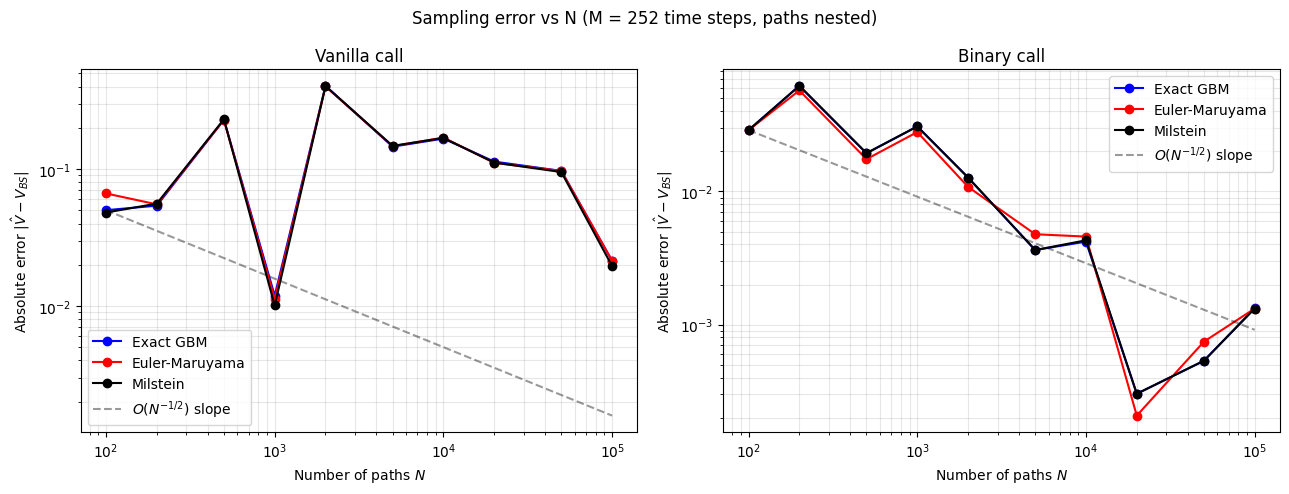

In [6]:
n_steps_fixed = 252
N_grid = np.array([100, 200, 500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000])
N_max = N_grid.max()

# One large block of randomness, shared across all schemes and all N values
rng = np.random.default_rng(seed)
Z_big = rng.standard_normal((N_max, n_steps_fixed))

err_van = {name: np.zeros(len(N_grid)) for name in schemes}
err_bin = {name: np.zeros(len(N_grid)) for name in schemes}

for i, N in enumerate(N_grid):
    Z = Z_big[:N, :]                              # prefix
    for name, fn in schemes.items():
        S_T = fn(S0, r, sigma, T, Z)
        mc_v = np.exp(-r * T) * vanilla_call_payoff(S_T, E).mean()
        mc_b = np.exp(-r * T) * binary_call_payoff(S_T, E).mean()
        err_van[name][i] = abs(mc_v - bs_vanilla_base)
        err_bin[name][i] = abs(mc_b - bs_binary_base)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['blue', 'red', 'black']
for (name, _), c in zip(schemes.items(), colors):
    axes[0].loglog(N_grid, err_van[name], 'o-', color=c, label=name)
    axes[1].loglog(N_grid, err_bin[name], 'o-', color=c, label=name)

for ax, ref_err in [(axes[0], err_van['Exact GBM'][0]),
                    (axes[1], err_bin['Exact GBM'][0])]:
    ref = ref_err * np.sqrt(N_grid[0] / N_grid)
    ax.loglog(N_grid, ref, 'k--', alpha=0.4, label=r'$O(N^{-1/2})$ slope')
    ax.set_xlabel(r'Number of paths $N$')
    ax.set_ylabel(r'Absolute error $|\hat V - V_{BS}|$')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()

axes[0].set_title('Vanilla call')
axes[1].set_title('Binary call')
fig.suptitle(f'Sampling error vs N (M = {n_steps_fixed} time steps, paths nested)')
plt.tight_layout()
plt.show()

The vanilla and binary panels both decay along the dashed $O(N^{-1/2})$ guide, confirming the theoretical rate. The three schemes overlap almost exactly because at $M = 252$ no scheme has meaningful discretisation bias — the curves represent sampling noise alone. The vanilla panel is non-monotone at small $N$ because the absolute error is itself a random variable, and at $N = 2{,}000$ the sample mean happens to land far from the truth. This is expected and disappears at larger $N$. The binary panel is smoother because the indicator payoff has lower absolute variance, even though its relative variance is higher.

### 2.3 Convergence: error vs number of time steps
Holding $N = 100{,}000$ fixed and varying the time-step count $M$ isolates the discretisation bias of each scheme. The three schemes have different theoretical convergence orders, derived as follows.

#### Why Exact GBM has zero bias
The lognormal transition law of GBM is exact, so $S_{t + \delta t} = S_t \exp \bigl((r - \tfrac{1}{2} \sigma^2) \delta t + \sigma \sqrt{\delta t} Z\bigr)$ has the correct distribution for any $\delta t$, large or small. Consequently $\mathbb{E}[\text{Payoff}(S_T^{\text{exact}})] = V_0^{\text{true}}$ exactly, and Exact GBM error reflects only sampling noise.

#### Euler-Maruyama and the dropped Itô term
Euler-Maruyama discretises $dS_t = r S_t dt + \sigma S_t dX_t$ as a first-order Taylor expansion,
$$
S_{t + \delta t} \approx S_t + r S_t \delta t + \sigma S_t \sqrt{\delta t} Z.
$$

This treats the diffusion coefficient $b(S_t) = \sigma S_t$ as constant over the step, which is exact for additive noise but wrong for multiplicative noise. Comparing against the exact log-step expansion, $S_{t + \delta t} = S_t [1 + (r - \tfrac{1}{2} \sigma^2) \delta t + \sigma \sqrt{\delta t} Z + \tfrac{1}{2} \sigma^2 \delta t Z^2 + O(\delta t^{3/2})]$, the Euler scheme is missing the $\tfrac{1}{2} \sigma^2 \delta t (Z^2 - 1)$ term plus the $-\tfrac{1}{2} \sigma^2 \delta t$ drift correction. The result is weak-order error $O(\delta t)$ in expected payoffs.

#### Milstein, derived from Itô's lemma
Milstein restores the missing term by applying Itô's lemma to the diffusion coefficient itself. The general Itô-Taylor expansion of an SDE $dS_t = a(S_t) dt + b(S_t) dX_t$ over a step $\delta t$ retains an extra cross-variation term beyond Euler,
$$
S_{t + \delta t} \approx S_t + a(S_t) \delta t + b(S_t) \int_t^{t + \delta t} dX_s + b(S_t) \frac{\partial b}{\partial S} \int_t^{t + \delta t} \int_t^s dX_u\, dX_s.
$$

The double Itô integral evaluates to $\tfrac{1}{2}\bigl[(X_{t + \delta t} - X_t)^2 - \delta t\bigr]$, which equals $\tfrac{1}{2} \delta t (Z^2 - 1)$ in our notation. For GBM with $a = r S_t$, $b = \sigma S_t$, $\tfrac{\partial b}{\partial S} = \sigma$, the Milstein correction is
$$
b(S_t) \frac{\partial b}{\partial S} \cdot \frac{1}{2} \delta t (Z^2 - 1) = \frac{1}{2} \sigma^2 S_t \delta t (Z^2 - 1),
$$
which gives the scheme
$$
S_{t + \delta t}^{\text{Milstein}} = S_t + r S_t \delta t + \sigma S_t \sqrt{\delta t} Z + \frac{1}{2} \sigma^2 S_t \delta t (Z^2 - 1).
$$

This raises strong order to $1$.

To make the schemes directly comparable, the same random matrix $Z$ drives all three, with each $M$ taking the first $M$ columns of one large $(N, M_{\max})$ block.

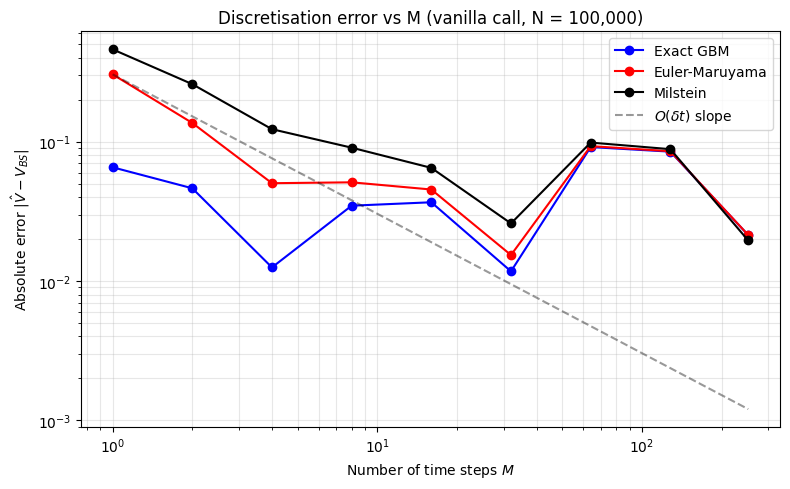

In [7]:
n_paths_fixed = 100_000
M_grid = np.array([1, 2, 4, 8, 16, 32, 64, 128, 252])
M_max = M_grid.max()

# One large block of randomness for all schemes; for each M, take the first M columns
# and rescale so they correspond to a single time-step partition of [0, T].
rng = np.random.default_rng(seed)
Z_big = rng.standard_normal((n_paths_fixed, M_max))

err_M = {name: np.zeros(len(M_grid)) for name in schemes}

for i, M in enumerate(M_grid):
    Z = Z_big[:, :M]    # prefix
    for name, fn in schemes.items():
        S_T = fn(S0, r, sigma, T, Z)
        mc_v = np.exp(-r * T) * vanilla_call_payoff(S_T, E).mean()
        err_M[name][i] = abs(mc_v - bs_vanilla_base)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['blue', 'red', 'black']
for (name, _), c in zip(schemes.items(), colors):
    ax.loglog(M_grid, err_M[name], 'o-', color=c, label=name)

ref = err_M['Euler-Maruyama'][0] * M_grid[0] / M_grid
ax.loglog(M_grid, ref, 'k--', alpha=0.4, label=r'$O(\delta t)$ slope')

ax.set_xlabel(r'Number of time steps $M$')
ax.set_ylabel(r'Absolute error $|\hat V - V_{BS}|$')
ax.set_title(f'Discretisation error vs M (vanilla call, N = {n_paths_fixed:,})')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Exact GBM stays flat near the sampling-noise floor (~$10^{-2}$) across all $M$, confirming zero discretisation bias. Euler and Milstein both start above 0.30 at $M = 1$ and decay along the $O(\delta t)$ guide. Milstein sits slightly below Euler at small $M$ as expected from its higher convergence order, though the gap is modest because the GBM Milstein correction $\tfrac{1}{2} \sigma^2 S_t \delta t (Z^2 - 1)$ has zero mean and only reduces variance of the bias rather than the bias itself in expectation. From $M \approx 64$ onwards, all three schemes merge — the discretisation error has fallen below the sampling-noise floor and is no longer distinguishable. This sets a practical guide where there is no benefit to taking $M > 64$ at $N = 100{,}000$ for this base case, since the bottleneck switches from bias to noise.

### 2.4 Parameter sensitivity
We sweep one input at a time, holding the others at the base case ($S_0 = 100$, $E = 100$, $T = 1$, $\sigma = 0.20$, $r = 0.05$). Pricing uses Exact GBM with $N = 100{,}000$ paths, the same shared random matrix across all parameter values within each sweep, so the curves reflect parameter response rather than Monte Carlo noise. Black-Scholes closed-form curves overlay each panel as the truth reference. The four sweeps are strike $E \in [70, 130]$, expiry $T \in \{0.25, 0.5, 0.75, 1.0, 1.5, 2.0\}$, volatility $\sigma \in [0.10, 0.40]$, and risk-free rate $r \in \{0.03, 0.04, 0.05, 0.06, 0.07\}$.

C:\Users\rexco\AppData\Local\Temp\ipykernel_23116\903927990.py:48: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  axes[0, col].plot(grid, bs_v, 'k-', color='black', label='Black-Scholes')
C:\Users\rexco\AppData\Local\Temp\ipykernel_23116\903927990.py:54: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  axes[1, col].plot(grid, bs_b, 'k-',  color='black', label='Black-Scholes')


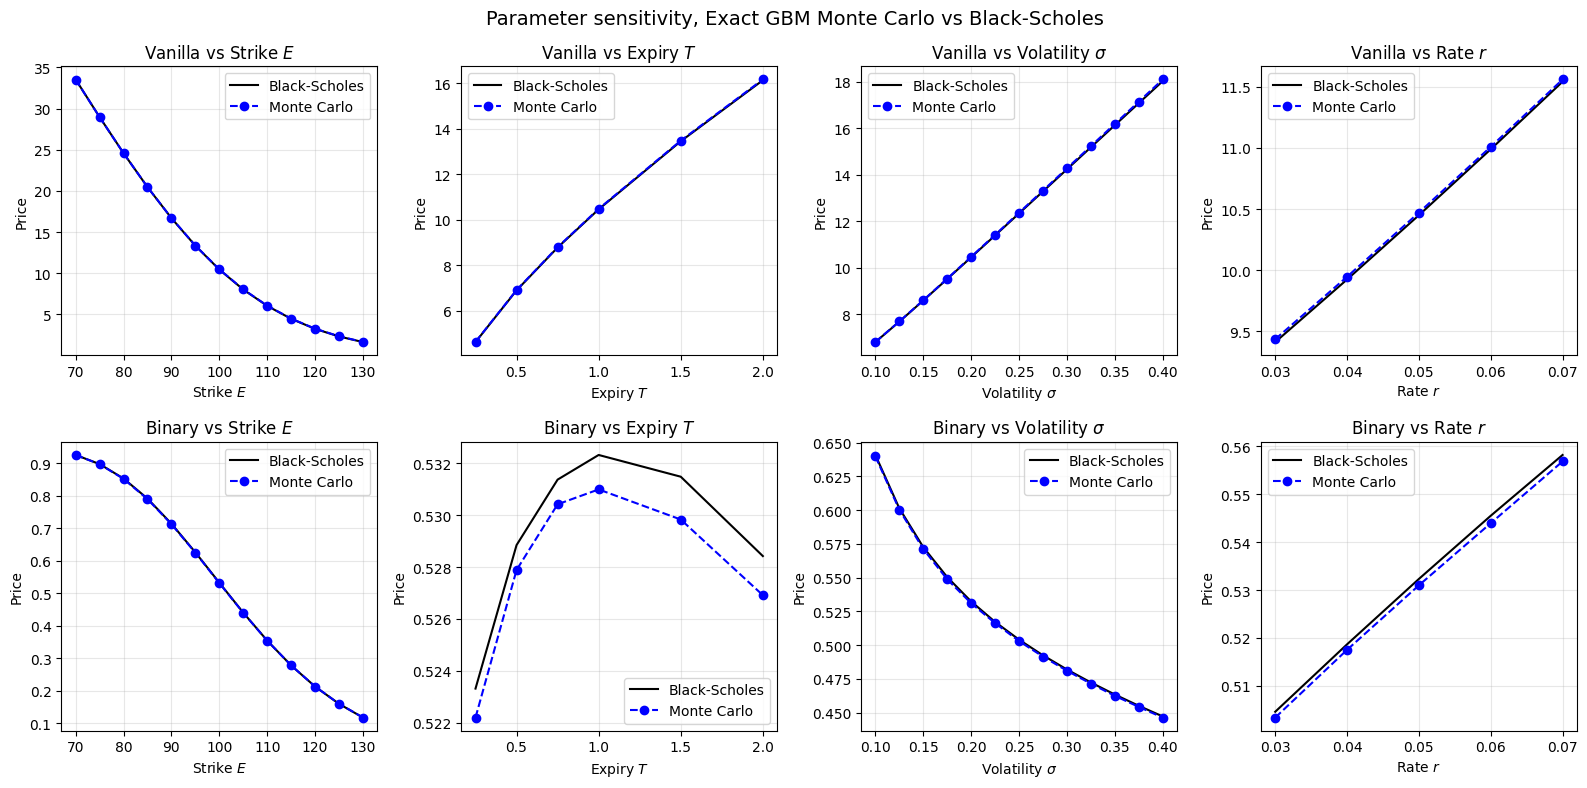

In [8]:
N_sens = 100_000
M_sens = 252

# Pre-draw one shared random block. We will rescale it per-T inside each call
# (rescaling is automatic because exact_gbm uses dt = T/n_steps).
rng = np.random.default_rng(seed)
Z_sens = rng.standard_normal((N_sens, M_sens))


def price_at(S0, E, T, r, sigma):
    """Exact GBM Monte Carlo prices for vanilla and binary call, on shared Z."""
    S_T = exact_gbm(S0, r, sigma, T, Z_sens)
    disc = np.exp(-r * T)
    return (disc * vanilla_call_payoff(S_T, E).mean(),
            disc * binary_call_payoff(S_T, E).mean())


# --- Sweep grids ---
E_grid     = np.linspace(70, 130, 13)
T_grid     = np.array([0.25, 0.5, 0.75, 1.0, 1.5, 2.0])
sigma_grid = np.linspace(0.10, 0.40, 13)
r_grid     = np.array([0.03, 0.04, 0.05, 0.06, 0.07])

sweeps = [
    ("Strike $E$",      E_grid,     lambda x: price_at(S0, x,  T,  r,  sigma),
                                    lambda x: (bs_vanilla_call(S0, x, T, r, sigma),
                                               bs_binary_call (S0, x, T, r, sigma))),
    ("Expiry $T$",      T_grid,     lambda x: price_at(S0, E,  x,  r,  sigma),
                                    lambda x: (bs_vanilla_call(S0, E, x, r, sigma),
                                               bs_binary_call (S0, E, x, r, sigma))),
    ("Volatility $\\sigma$", sigma_grid, lambda x: price_at(S0, E, T, r, x),
                                    lambda x: (bs_vanilla_call(S0, E, T, r, x),
                                               bs_binary_call (S0, E, T, r, x))),
    ("Rate $r$",        r_grid,     lambda x: price_at(S0, E,  T,  x,  sigma),
                                    lambda x: (bs_vanilla_call(S0, E, T, x, sigma),
                                               bs_binary_call (S0, E, T, x, sigma))),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, (label, grid, mc_fn, bs_fn) in enumerate(sweeps):
    mc_v = np.zeros(len(grid)); mc_b = np.zeros(len(grid))
    bs_v = np.zeros(len(grid)); bs_b = np.zeros(len(grid))
    for i, x in enumerate(grid):
        mc_v[i], mc_b[i] = mc_fn(x)
        bs_v[i], bs_b[i] = bs_fn(x)

    axes[0, col].plot(grid, bs_v, 'k-', color='black', label='Black-Scholes')
    axes[0, col].plot(grid, mc_v, 'o--', color='blue', label='Monte Carlo')
    axes[0, col].set_title(f'Vanilla vs {label}')
    axes[0, col].set_xlabel(label); axes[0, col].set_ylabel('Price')
    axes[0, col].grid(alpha=0.3); axes[0, col].legend()

    axes[1, col].plot(grid, bs_b, 'k-',  color='black', label='Black-Scholes')
    axes[1, col].plot(grid, mc_b, 'o--', color='blue', label='Monte Carlo')
    axes[1, col].set_title(f'Binary vs {label}')
    axes[1, col].set_xlabel(label); axes[1, col].set_ylabel('Price')
    axes[1, col].grid(alpha=0.3); axes[1, col].legend()

fig.suptitle('Parameter sensitivity, Exact GBM Monte Carlo vs Black-Scholes',
             fontsize=14)
plt.tight_layout()
plt.show()

Monte Carlo tracks Black-Scholes closely across all eight panels, validating both the simulator and the closed-form pricers across a wide region of parameter space. The vanilla call is monotone in all four inputs, increasing in $T$, $\sigma$ and $r$, and decreasing in $E$. The strike panel is convex (typical of vanilla options), and the volatility panel is near-linear at the money where vega is roughly constant.

The binary call shows three behaviours that differ qualitatively from the vanilla. First, the binary price decreases in $\sigma$, opposite to the vanilla. The intuition is that an at-the-money binary has its peak value when there is no uncertainty at all, since $S_T$ near $E$ gives $N(d_2) \approx 0.5$ with full discount benefit. Adding volatility spreads probability mass into both tails symmetrically and therefore reduces $\mathbb{P}^{\mathbb{Q}}[S_T > E]$ from below 0.5 in the lognormal case. Second, the binary is non-monotone in $T$, peaking near $T = 1$ then decaying. The same uncertainty argument applies, more time means more chance of finishing below $E$ as well as above. Third, the binary panel for $T$ shows a small but visible gap between Monte Carlo and Black-Scholes. This is sampling noise rather than scheme bias, because the binary payoff has Bernoulli variance $p(1-p)$ which is largest near $p = 0.5$ — exactly the regime our base case is in.

### 2.5 Antithetic variates
Antithetic variates is a variance-reduction technique that exploits the symmetry of the standard normal distribution. For each draw $Z$, we also use $-Z$ and average the two payoffs into a single combined estimator. Because $S_T(Z)$ and $S_T(-Z)$ are negatively correlated, the variance of their average is smaller than the variance of two independent draws.

#### Variance derivation
Let $Y_j := \text{Payoff}(Z_j)$ and $Y'_j := \text{Payoff}(-Z_j)$. Each pair contributes $Z_j := \tfrac{1}{2}(Y_j + Y'_j)$ to the antithetic estimator. Note that $Y_j$ and $Y'_j$ have the same distribution because $Z$ and $-Z$ are both standard normal, so $\text{Var}(Y_j) = \text{Var}(Y'_j) = \sigma_Y^2$. Using the standard variance identity for a sum,

$$
\text{Var}(Z_j) = \frac{1}{4} \text{Var}(Y_j + Y'_j) = \frac{1}{4}\bigl[\text{Var}(Y_j) + \text{Var}(Y'_j) + 2 \text{Cov}(Y_j,\, Y'_j)\bigr].
$$

Substituting and writing $\rho := \text{Corr}(Y_j,\, Y'_j) = \text{Cov}(Y_j,\, Y'_j) / \sigma_Y^2$,

$$
\text{Var}(Z_j) = \frac{1}{4}\bigl[2 \sigma_Y^2 + 2 \rho \sigma_Y^2\bigr] = \frac{\sigma_Y^2}{2}(1 + \rho).
$$

The antithetic estimator $\hat{V}_{\text{AV}} = e^{-r T} \tfrac{1}{N} \sum_{j=1}^N Z_j$ then has standard error

$$
\text{SE}(\hat{V}_{\text{AV}}) = e^{-r T} \frac{\sigma_Y}{\sqrt{2 N}} \sqrt{1 + \rho}.
$$

For comparison, the standard estimator using $2 N$ independent paths has $\text{SE} = e^{-r T} \sigma_Y / \sqrt{2 N}$, so the antithetic-to-standard standard-error ratio at matched compute is $\sqrt{1 + \rho}$. Whenever $\rho < 0$ the antithetic estimator wins, and the ratio reaches zero in the limit $\rho = -1$.

#### Why $\rho < 0$ for the vanilla call
For GBM, $S_T(Z) = S_0 \exp \bigl((r - \tfrac{1}{2} \sigma^2) T + \sigma \sqrt{T}\, Z\bigr)$ is monotone increasing in $Z$, and $S_T(-Z)$ is monotone decreasing. The vanilla call payoff $\max(S_T - E,\, 0)$ is itself non-decreasing in $S_T$, so $Y_j$ and $Y'_j$ are countermonotone whenever both are non-zero. This produces $\rho < 0$ and the technique works. For the binary call, the indicator payoff has only two values, $0$ and $1$, so the negative correlation between paired payoffs is weaker and the variance reduction would be smaller.

The comparison below uses matched compute budgets, $N$ standard paths versus $N/2$ antithetic pairs, both consuming $N$ payoff evaluations. 

 N (total paths)  Standard SE  Antithetic SE  SE reduction factor
             200      0.99287        0.71206              1.39436
             500      0.63206        0.45720              1.38246
            1000      0.44740        0.31395              1.42507
            2000      0.33628        0.22072              1.52361
            5000      0.20842        0.14931              1.39583
           10000      0.14614        0.10532              1.38759
           20000      0.10527        0.07340              1.43413
           50000      0.06620        0.04692              1.41100
          100000      0.04677        0.03303              1.41609


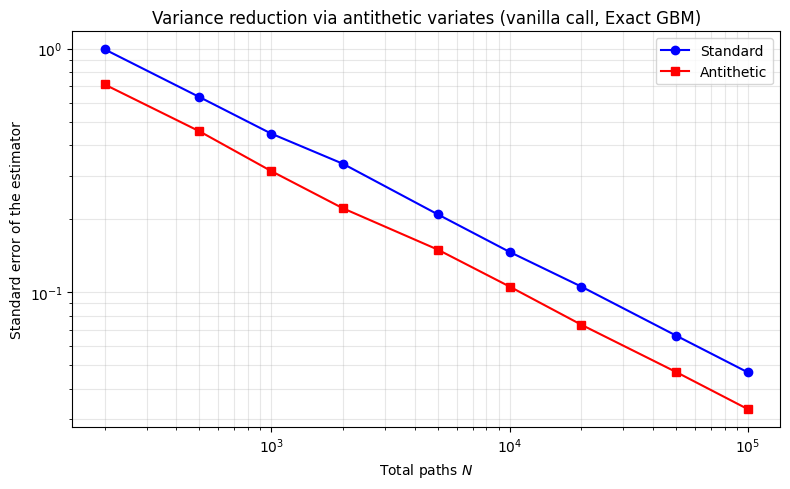

In [9]:
def mc_price_antithetic(scheme_fn, payoff_fn, S0, E, T, r, sigma,
                        n_pairs, n_steps, seed_local):
    """Antithetic variant. Uses n_pairs draws + their negatives = 2*n_pairs paths."""
    rng = np.random.default_rng(seed_local)
    Z = rng.standard_normal((n_pairs, n_steps))
    Z_full = np.concatenate([Z, -Z], axis=0)         # (2*n_pairs, n_steps)
    S_T = scheme_fn(S0, r, sigma, T, Z_full)
    payoffs = payoff_fn(S_T, E)

    # Pair the payoffs and average within each pair before taking the grand mean
    pair_means = 0.5 * (payoffs[:n_pairs] + payoffs[n_pairs:])
    price = np.exp(-r * T) * pair_means.mean()
    se    = np.exp(-r * T) * pair_means.std(ddof=1) / np.sqrt(n_pairs)
    return price, se


def mc_price_standard(scheme_fn, payoff_fn, S0, E, T, r, sigma,
                      n_paths, n_steps, seed_local):
    """Standard estimator with reported standard error."""
    rng = np.random.default_rng(seed_local)
    Z = rng.standard_normal((n_paths, n_steps))
    S_T = scheme_fn(S0, r, sigma, T, Z)
    payoffs = payoff_fn(S_T, E)
    price = np.exp(-r * T) * payoffs.mean()
    se    = np.exp(-r * T) * payoffs.std(ddof=1) / np.sqrt(n_paths)
    return price, se


# Sweep N to compare standard error of the two estimators at matched compute
N_grid_av = np.array([200, 500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000])

se_std = np.zeros(len(N_grid_av))
se_av  = np.zeros(len(N_grid_av))

for i, N in enumerate(N_grid_av):
    _, se_std[i] = mc_price_standard(exact_gbm, vanilla_call_payoff,
                                     S0, E, T, r, sigma, N, M_sens, seed)
    # Antithetic uses N/2 pairs to keep total path count the same
    _, se_av[i]  = mc_price_antithetic(exact_gbm, vanilla_call_payoff,
                                       S0, E, T, r, sigma, N // 2, M_sens, seed)

reduction = se_std / se_av  # how much smaller the antithetic SE is

table_av = pd.DataFrame({
    "N (total paths)":     N_grid_av,
    "Standard SE":         se_std,
    "Antithetic SE":       se_av,
    "SE reduction factor": reduction,
}).round(5)

print(table_av.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(N_grid_av, se_std, 'o-', color='blue', label='Standard')
ax.loglog(N_grid_av, se_av,  's-', color='red', label='Antithetic')
ax.set_xlabel('Total paths $N$')
ax.set_ylabel('Standard error of the estimator')
ax.set_title('Variance reduction via antithetic variates (vanilla call, Exact GBM)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

The antithetic estimator's standard error sits consistently below the standard estimator across every $N$ on the grid, with a reduction factor near 1.40 throughout. Squared, this is a variance reduction of roughly 1.96, so the antithetic estimator at $N$ paths achieves the same precision as the standard estimator at nearly $2 N$ paths — effectively halving the required compute. The reduction factor is stable across $N$ because $\rho$ is a property of the payoff function and the dynamics, not of the sample size. From the observed reduction factor we can back out $\rho \approx 1 / (1.40)^2 - 1 \approx -0.49$, indicating substantial negative correlation between paired payoffs for the at-the-money vanilla call.

## 3. Observations and Problems Encountered
### 3.1 The bottleneck switches between sampling and discretisation
The most useful observation from this project is that the dominant error source depends on the regime. At small $M$ with large $N$, discretisation bias dominates and Milstein beats Euler. At large $M$ with moderate $N$, sampling noise dominates and scheme choice becomes irrelevant — Section 2.3 shows all three schemes merging at $M \approx 64$. There is no universal answer to "which scheme should I use". The right answer depends on whether the compute budget is bounded by paths or by steps. For a path-independent payoff under GBM, the rational allocation is $M = 1$ with Exact GBM and all compute spent on $N$, since Exact has no bias. Euler and Milstein only become necessary when the SDE has no closed-form transition law for example, CIR or Heston.

### 3.2 The binary call breaks vanilla intuition
The binary call's response to volatility in Section 2.4 was the most counterintuitive result. A trader's instinct is "more volatility means more option value", which is true for vanilla but reversed for an at-the-money binary. The binary price is $e^{-r T} N(d_2)$ where $d_2 = [\ln(S_0/E) + (r - \tfrac{1}{2} \sigma^2) T] / (\sigma \sqrt{T})$. At the money with $S_0 = E$, $d_2 = (r/\sigma - \tfrac{1}{2} \sigma) \sqrt{T}$, which is always decreasing in $\sigma$. Differentiating, $\partial B_c / \partial \sigma = -e^{-r T} \phi(d_2) \frac{d_1}{\sigma} < 0$ at the money. So the negative vega of the at-the-money binary is structural. This is crucial in practice because hedging an at-the-money binary requires the opposite vega trade compared to its vanilla counterpart.

### 3.3 Problems encountered
Two key implementation issues arose during development. (i) The first version of the convergence study (Section 2.2) used independent random draws for each $N$ on the grid, producing a jagged curve that misled interpretation. Switching to the nested-path protocol (one $(N_{\max}, M)$ matrix prefixed for each $N$) made the $O(N^{-1/2})$ rate visually obvious. (ii) The first version of the discretisation study (Section 2.3) similarly used independent draws for each $M$, so the $O(\delta t)$ rate of Euler and Milstein was buried in scheme-to-scheme noise. Sharing one $(N, M_{\max})$ matrix across all schemes and prefixing for each $M$ exposed the rates cleanly.

## 4. Conclusion
This project priced a vanilla European call and a binary call by Monte Carlo simulation under three discretisation schemes (Exact GBM, Euler-Maruyama, Milstein), benchmarked against Black-Scholes closed forms, and studied how the pricing error responds to compute and to the four pricing parameters.

Three results worth highlighting. First, all three schemes recover the Black-Scholes prices to within sampling noise on the base case, with absolute sampling error decaying as $O(N^{-1/2})$ and discretisation error decaying as $O(\delta t)$ for Euler and Milstein, exactly as theory predicts. Second, the dominant error source flips between sampling and discretisation depending on the regime. At $M \approx 64$ steps with $N = 100{,}000$ paths, all three schemes merge — beyond that point the bottleneck is paths, not steps, so there is no benefit to a higher-order scheme. Third, the binary call's vega is structurally negative at the money, opposite to the vanilla call. The closed-form derivative $\partial B_c / \partial \sigma = -e^{-r T} \phi(d_2) \frac{d_1}{\sigma} < 0$ confirms the Monte Carlo finding.

Antithetic variates delivered a ~1.40$\times$ standard-error reduction at matched compute, equivalent to halving the path count required for a given precision. The technique is essentially free to implement and should be the default for any payoff that is monotone in the underlying.

For practical pricing of European options under GBM, the recommendation is Exact GBM with $M = 1$ for path-independent payoffs and antithetic variates always on, since neither costs anything beyond a few lines of code. Euler-Maruyama and Milstein become necessary only when the SDE lacks a closed-form transition step, for example in stochastic-volatility or short-rate models, in which case Milstein's $O(\delta t)$ convergence justifies the small extra cost over Euler.

## 5. References
- Wilmott, P. (2006). *Paul Wilmott on Quantitative Finance*, 2nd ed
- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*. Springer
- Hull, J. (2018). *Options, Futures, and Other Derivatives*, 10th ed
- CQF Module 3 lectures and Python labs
- CQF tutorial note "Milstein Integration"